Домашняя работа 3

Выполнила: Питецкая Е.Т.

Группа: 737-01

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import requests
import io
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

ЧАСТЬ 1: РАЗВЕДОЧНЫЙ АНАЛИЗ (40%)

In [2]:
# 1.1 Загрузка данных
url = "https://raw.githubusercontent.com/KateAndri/StudyRepo26/main/data/dispensarization_data_2026.csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))

print(f"Данные загружены. Размер: {df.shape}")


Данные загружены. Размер: (1000, 18)


In [5]:
# 1.2 Описание структуры датасета
print(f"   - Количество строк: {df.shape[0]}")
print(f"   - Количество столбцов: {df.shape[1]}")
print(f"\n   Типы данных:")
print(df.dtypes.value_counts())
print(f"\n   Колонки: {df.columns.tolist()}")

# Проверка пропусков
print("\n   Пропуски в данных:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("Пропусков нет")
# Статистика
print("\n   Статистика числовых признаков:")
print(df.describe().round(2))


   - Количество строк: 1000
   - Количество столбцов: 18

   Типы данных:
float64    12
int64       6
Name: count, dtype: int64

   Колонки: ['Возраст', 'Пол_мужской', 'ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст', 'Пульсовое_давление', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин', 'Курение', 'Физическая_активность_мин_нед', 'ССЗ_риск_высокий', 'Статус_глюкозы', 'Доклинический_риск']

   Пропуски в данных:
ЛПНП_ммоль_л            45
ЛПВП_ммоль_л            56
Триглицериды_ммоль_л    61
СКФ_мл_мин              61
dtype: int64

   Статистика числовых признаков:
       Возраст  Пол_мужской      ИМТ  Окружность_талии_см  САД_мм_рт_ст  \
count  1000.00      1000.00  1000.00              1000.00       1000.00   
mean     52.39         0.44    23.56                86.17        114.18   
std       7.59         0.50     3.22                 6.01         10.99   
min      40.00         0.00    16.00                68.86

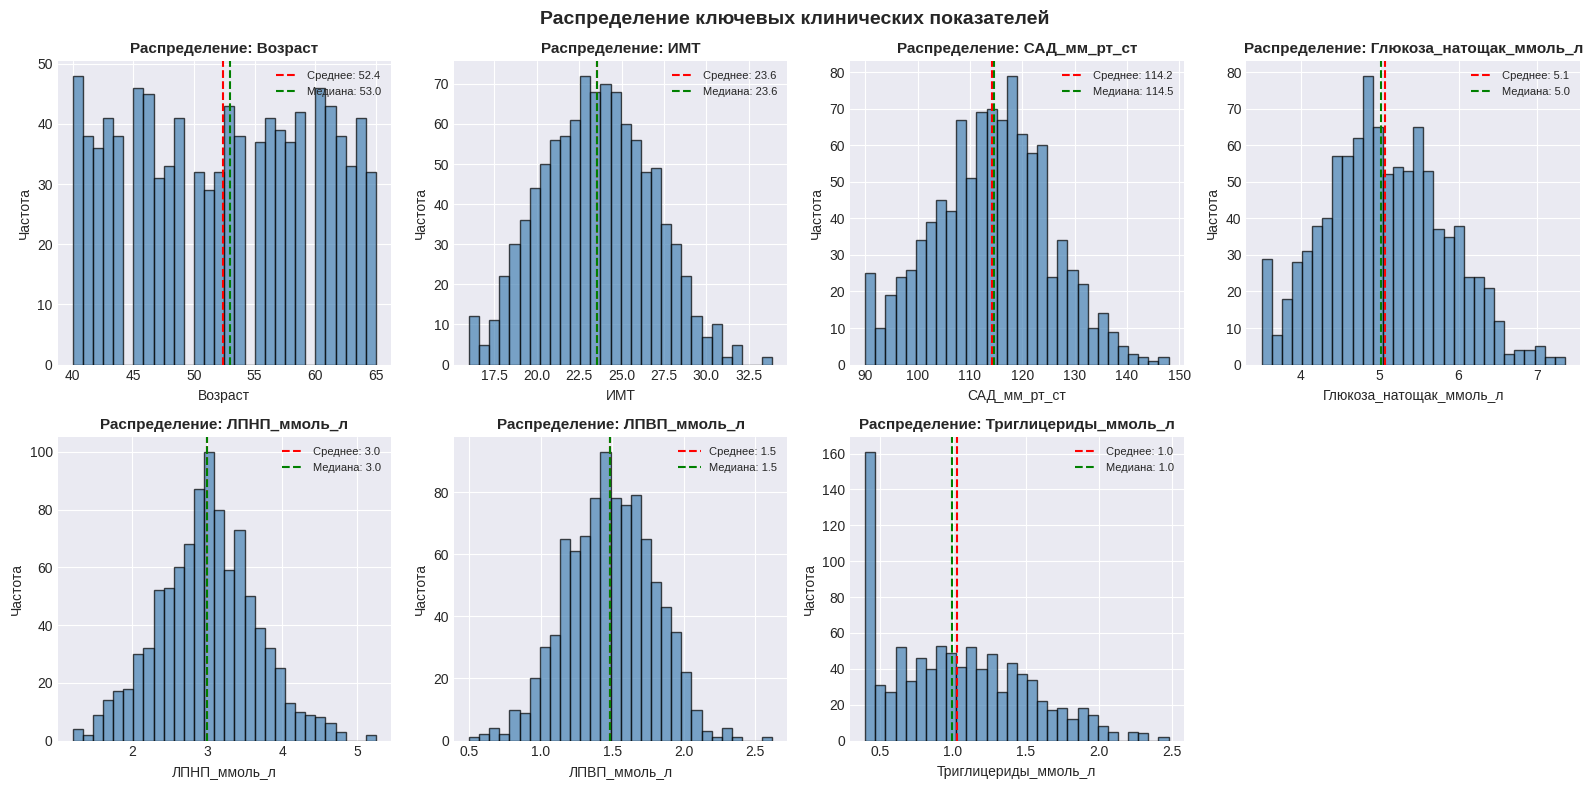

In [7]:
# 1.3 Гистограммы ключевых показателей
key_features = ['Возраст', 'ИМТ', 'САД_мм_рт_ст', 'Глюкоза_натощак_ммоль_л',
                'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if feature in df.columns:
        axes[i].hist(df[feature].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(f'Распределение: {feature}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Частота')
        axes[i].axvline(df[feature].mean(), color='red', linestyle='--', label=f'Среднее: {df[feature].mean():.1f}')
        axes[i].axvline(df[feature].median(), color='green', linestyle='--', label=f'Медиана: {df[feature].median():.1f}')
        axes[i].legend(fontsize=8)
  # Убираем пустой подграфик
if len(key_features) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Распределение ключевых клинических показателей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

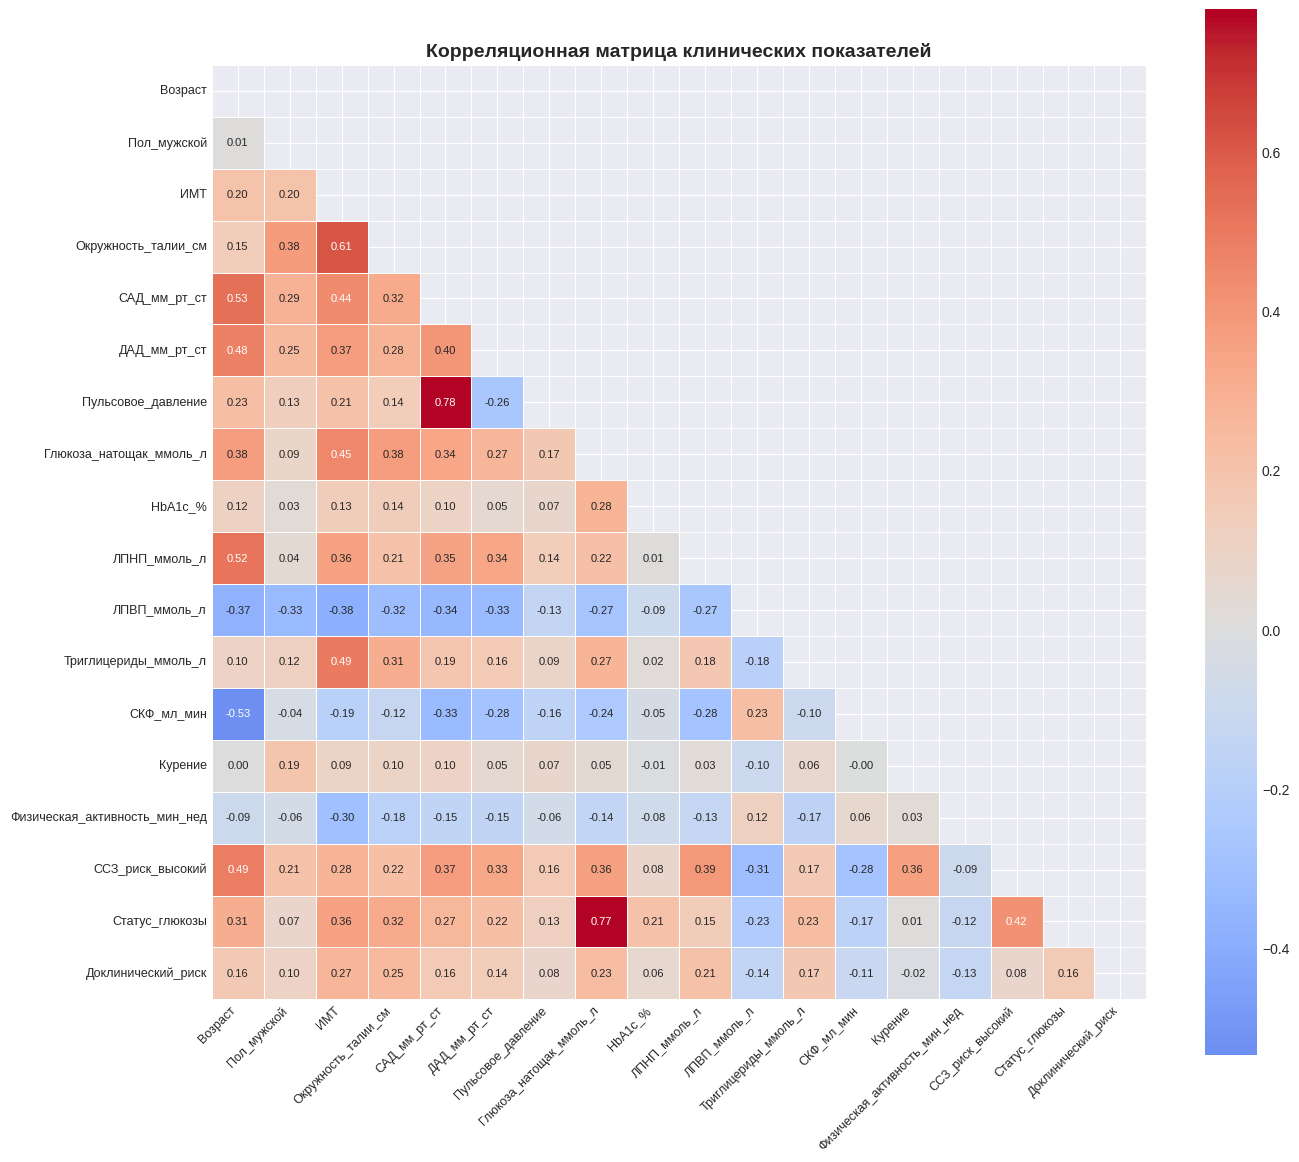

In [8]:
# 1.4 Корреляционная матрица
# Выбираем числовые колонки
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Корреляционная матрица клинических показателей', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

             Показатель  Выбросов  Процент  Нижняя граница  Верхняя граница
                Возраст         0      0.0           26.50            78.50
                    ИМТ         2      0.2           14.12            32.89
           САД_мм_рт_ст         3      0.3           84.83           143.63
Глюкоза_натощак_ммоль_л         3      0.3            2.96             7.16
           ЛПНП_ммоль_л         8      0.8            1.28             4.71
           ЛПВП_ммоль_л         5      0.5            0.64             2.33
   Триглицериды_ммоль_л         0      0.0           -0.48             2.49


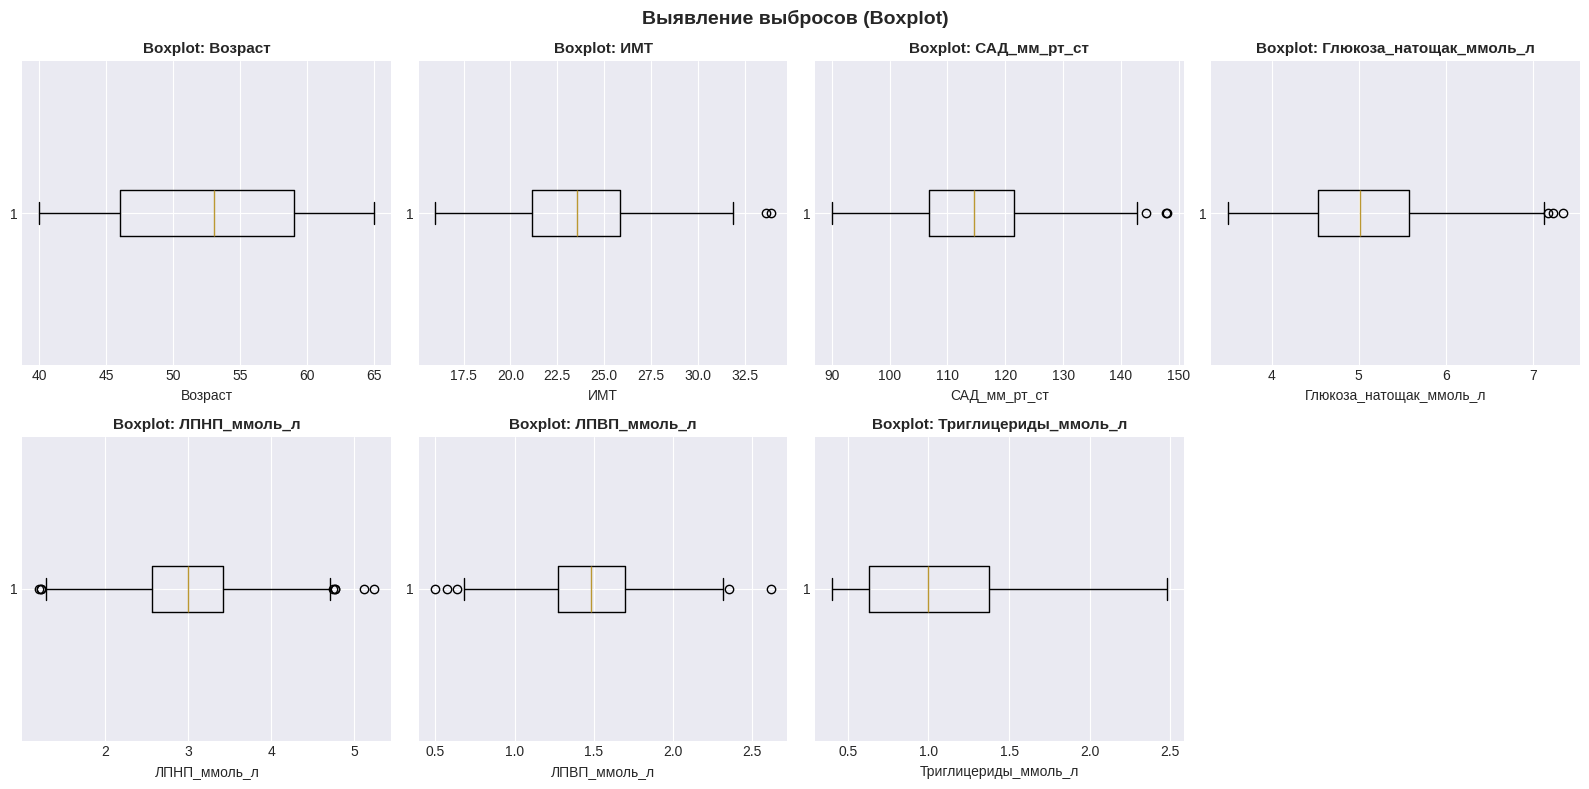

In [9]:
# 1.5 Выявление выбросов
outliers_summary = []
for col in key_features:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_summary.append({
            'Показатель': col,
            'Выбросов': len(outliers),
            'Процент': len(outliers) / len(df) * 100,
            'Нижняя граница': round(lower_bound, 2),
            'Верхняя граница': round(upper_bound, 2)
        })

outliers_df = pd.DataFrame(outliers_summary)
print(outliers_df.to_string(index=False))

# Визуализация выбросов с помощью boxplot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if feature in df.columns:
        axes[i].boxplot(df[feature].dropna(), vert=False)
        axes[i].set_title(f'Boxplot: {feature}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(feature)

if len(key_features) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Выявление выбросов (Boxplot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ЧАСТЬ 2: PCA АНАЛИЗ (40%)

In [12]:
# 2.1 Подготовка признаков для PCA (7 клинических показателей)
pca_features = ['Возраст', 'ИМТ', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст',
                'Глюкоза_натощак_ммоль_л', 'ЛПНП_ммоль_л', 'Триглицериды_ммоль_л']

X_pca = df[pca_features].copy()

# Обработка пропусков
print("\n2.1.1 Обработка пропусков...")
print(f"   Пропусков до обработки: {X_pca.isnull().sum().sum()}")
for col in X_pca.columns:
    if X_pca[col].isnull().sum() > 0:
        median_val = X_pca[col].median()
        X_pca[col].fillna(median_val, inplace=True)
        print(f"   {col}: заполнено медианой ({median_val:.2f})")
print(f"   Пропусков после обработки: {X_pca.isnull().sum().sum()}")


2.1 Подготовка признаков для PCA...

2.1.1 Обработка пропусков...
   Пропусков до обработки: 106
   ЛПНП_ммоль_л: заполнено медианой (3.00)
   Триглицериды_ммоль_л: заполнено медианой (1.00)
   Пропусков после обработки: 0


In [13]:
# 2.2 Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)
print("Данные стандартизированы")


Данные стандартизированы


In [15]:
# 2.3 Применение PCA с 3 компонентами
pca = PCA(n_components=3)
X_pca_result = pca.fit_transform(X_scaled)

# Добавляем результаты PCA в DataFrame
df['PC1'] = X_pca_result[:, 0]
df['PC2'] = X_pca_result[:, 1]
df['PC3'] = X_pca_result[:, 2]

print(f"PCA выполнен. Форма результата: {X_pca_result.shape}")

PCA выполнен. Форма результата: (1000, 3)


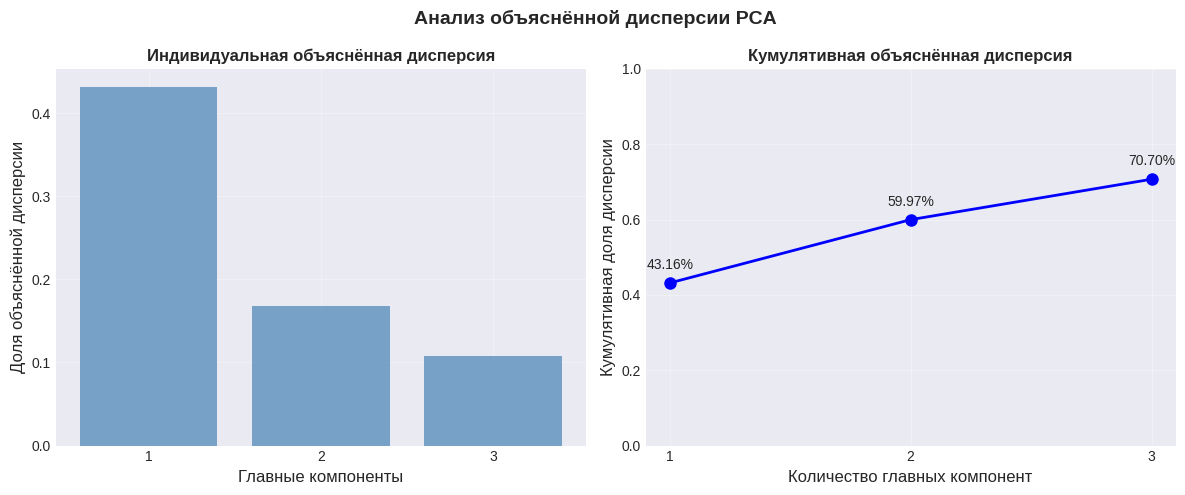


   Объяснённая дисперсия:
   PC1: 43.16%
   PC2: 16.81%
   PC3: 10.73%
   Суммарно (3 компоненты): 70.70%


In [16]:
# 2.4 Визуализация доли объяснённой дисперсии
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Индивидуальная дисперсия
axes[0].bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Главные компоненты', fontsize=12)
axes[0].set_ylabel('Доля объяснённой дисперсии', fontsize=12)
axes[0].set_title('Индивидуальная объяснённая дисперсия', fontweight='bold')
axes[0].set_xticks(range(1, 4))
axes[0].grid(True, alpha=0.3)

# Кумулятивная дисперсия
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество главных компонент', fontsize=12)
axes[1].set_ylabel('Кумулятивная доля дисперсии', fontsize=12)
axes[1].set_title('Кумулятивная объяснённая дисперсия', fontweight='bold')
axes[1].set_xticks(range(1, 4))
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Добавляем значения на график
for i, (ind, cum) in enumerate(zip(range(1, 4), cumulative_variance)):
    axes[1].annotate(f'{cum:.2%}', (ind, cum), textcoords="offset points", xytext=(0, 10), ha='center')

plt.suptitle('Анализ объяснённой дисперсии PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n   Объяснённая дисперсия:")
print(f"   PC1: {explained_variance[0]:.2%}")
print(f"   PC2: {explained_variance[1]:.2%}")
print(f"   PC3: {explained_variance[2]:.2%}")
print(f"   Суммарно (3 компоненты): {cumulative_variance[2]:.2%}")

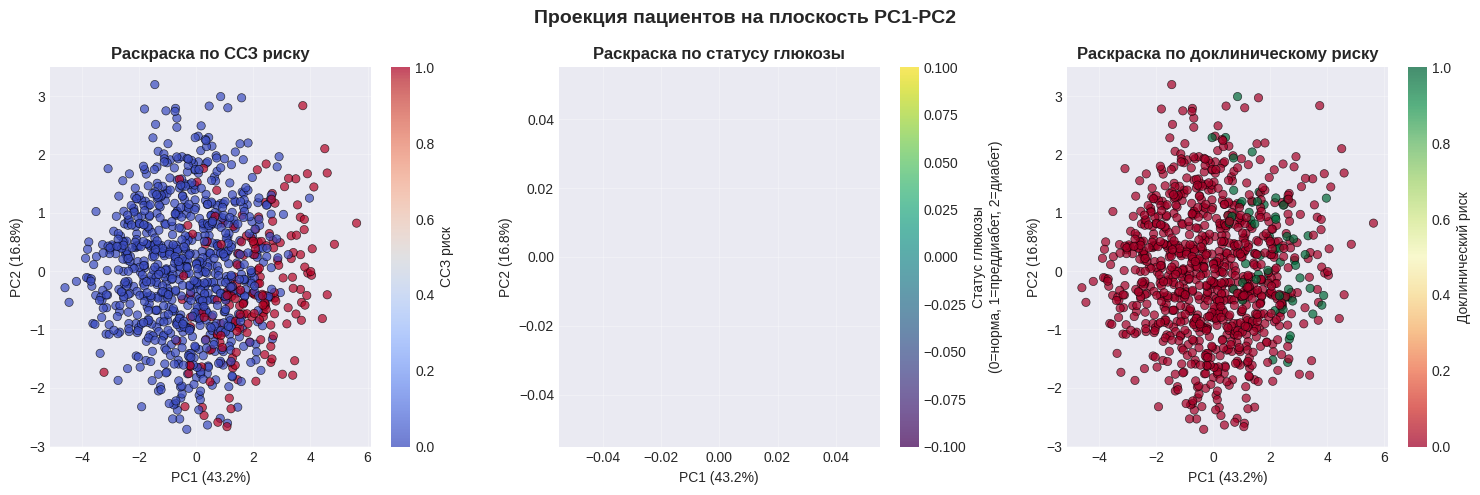

In [17]:
# 2.5 Построение проекции PC1 vs PC2 с раскраской
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Проекция по ССЗ-риску
if 'ССЗ_риск_высокий' in df.columns:
    scatter1 = axes[0].scatter(df['PC1'], df['PC2'], c=df['ССЗ_риск_высокий'],
                                cmap='coolwarm', alpha=0.7, edgecolors='black', linewidth=0.5)
    axes[0].set_title('Раскраска по ССЗ риску', fontweight='bold')
    axes[0].set_xlabel(f'PC1 ({explained_variance[0]:.1%})')
    axes[0].set_ylabel(f'PC2 ({explained_variance[1]:.1%})')
    plt.colorbar(scatter1, ax=axes[0], label='ССЗ риск')
    axes[0].grid(True, alpha=0.3)

# Проекция по статусу глюкозы
if 'Статус_глюкозы' in df.columns:
    glucose_status = df['Статус_глюкозы'].map({'норма': 0, 'преддиабет': 1, 'диабет': 2})
    scatter2 = axes[1].scatter(df['PC1'], df['PC2'], c=glucose_status,
                                cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5)
    axes[1].set_title('Раскраска по статусу глюкозы', fontweight='bold')
    axes[1].set_xlabel(f'PC1 ({explained_variance[0]:.1%})')
    axes[1].set_ylabel(f'PC2 ({explained_variance[1]:.1%})')
    plt.colorbar(scatter2, ax=axes[1], label='Статус глюкозы\n(0=норма, 1=преддиабет, 2=диабет)')
    axes[1].grid(True, alpha=0.3)

# Проекция по доклиническому риску
if 'Доклинический_риск' in df.columns:
    scatter3 = axes[2].scatter(df['PC1'], df['PC2'], c=df['Доклинический_риск'],
                                cmap='RdYlGn', alpha=0.7, edgecolors='black', linewidth=0.5)
    axes[2].set_title('Раскраска по доклиническому риску', fontweight='bold')
    axes[2].set_xlabel(f'PC1 ({explained_variance[0]:.1%})')
    axes[2].set_ylabel(f'PC2 ({explained_variance[1]:.1%})')
    plt.colorbar(scatter3, ax=axes[2], label='Доклинический риск')
    axes[2].grid(True, alpha=0.3)

plt.suptitle('Проекция пациентов на плоскость PC1-PC2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


   Нагрузки (loadings) признаков на главные компоненты:
                           PC1    PC2    PC3
Возраст                  0.415 -0.451  0.054
ИМТ                      0.410  0.440 -0.050
САД_мм_рт_ст             0.420 -0.157  0.170
ДАД_мм_рт_ст             0.385 -0.214  0.012
Глюкоза_натощак_ммоль_л  0.363  0.210  0.670
ЛПНП_ммоль_л             0.366 -0.250 -0.632
Триглицериды_ммоль_л     0.262  0.653 -0.342


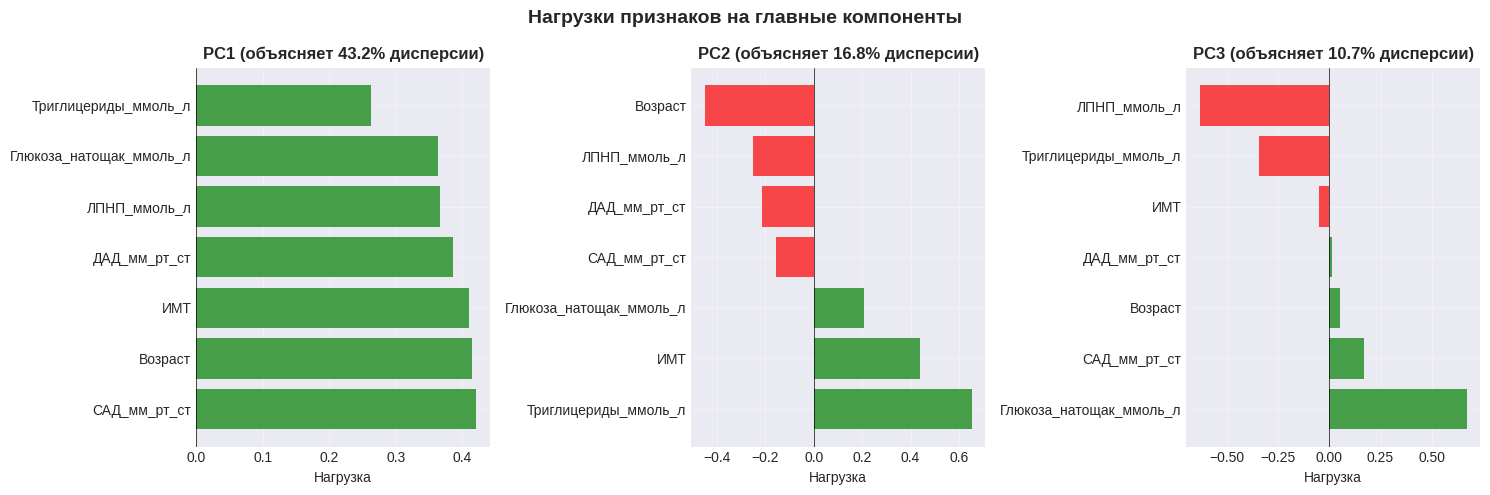


   Интерпретация компонент:
   PC1 (объясняет 43.2%):
      + Положительные нагрузки: ['САД_мм_рт_ст', 'Возраст', 'ИМТ']
      - Отрицательные нагрузки: ['Триглицериды_ммоль_л', 'Глюкоза_натощак_ммоль_л', 'ЛПНП_ммоль_л']
      Вывод: PC1 характеризует метаболический синдром

   PC2 (объясняет 16.8%):
      Наибольшие нагрузки: ['Триглицериды_ммоль_л', 'ИМТ']
      Вывод: PC2 характеризует липидный профиль


In [18]:
# 2.6 Интерпретация нагрузок (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=pca_features
)

print("\n   Нагрузки (loadings) признаков на главные компоненты:")
print(loadings.round(3))

# Визуализация нагрузок
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    component = f'PC{i+1}'
    loadings_sorted = loadings[component].sort_values(ascending=False)
    colors = ['red' if x < 0 else 'green' for x in loadings_sorted.values]
    ax.barh(range(len(loadings_sorted)), loadings_sorted.values, color=colors, alpha=0.7)
    ax.set_yticks(range(len(loadings_sorted)))
    ax.set_yticklabels(loadings_sorted.index)
    ax.set_xlabel('Нагрузка')
    ax.set_title(f'{component} (объясняет {explained_variance[i]:.1%} дисперсии)', fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.suptitle('Нагрузки признаков на главные компоненты', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n   Интерпретация компонент:")
print(f"   PC1 (объясняет {explained_variance[0]:.1%}):")
positive_pc1 = loadings['PC1'].nlargest(3).index.tolist()
negative_pc1 = loadings['PC1'].nsmallest(3).index.tolist()
print(f"      + Положительные нагрузки: {positive_pc1}")
print(f"      - Отрицательные нагрузки: {negative_pc1}")
print(f"      Вывод: PC1 характеризует метаболический синдром")

print(f"\n   PC2 (объясняет {explained_variance[1]:.1%}):")
positive_pc2 = loadings['PC2'].nlargest(2).index.tolist()
print(f"      Наибольшие нагрузки: {positive_pc2}")
print(f"      Вывод: PC2 характеризует липидный профиль")

ЧАСТЬ 3: ВЫЯВЛЕНИЕ ДОКЛИНИЧЕСКИХ НАРУШЕНИЙ (20%)

In [19]:
# 3.1 Определение порога для PC1 (90-й перцентиль)
pc1_threshold = df['PC1'].quantile(0.90)
print(f"   90-й перцентиль PC1: {pc1_threshold:.3f}")
print(f"   Количество пациентов выше порога: {(df['PC1'] > pc1_threshold).sum()} из {len(df)}")

   90-й перцентиль PC1: 2.257
   Количество пациентов выше порога: 100 из 1000


In [20]:
# 3.2 Определение нормальных значений показателей
normal_ranges = {
    'ИМТ': ('Индекс массы тела', 0, 25, 'кг/м²'),
    'Глюкоза_натощак_ммоль_л': ('Глюкоза натощак', 0, 5.6, 'ммоль/л'),
    'САД_мм_рт_ст': ('Систолическое АД', 0, 120, 'мм рт. ст.')
}

print("   Используемые нормальные значения (клинические рекомендации):")
for key, (name, _, normal, unit) in normal_ranges.items():
    print(f"      {name}: < {normal} {unit}")

   Используемые нормальные значения (клинические рекомендации):
      Индекс массы тела: < 25 кг/м²
      Глюкоза натощак: < 5.6 ммоль/л
      Систолическое АД: < 120 мм рт. ст.


In [21]:
# 3.3 Отбор пациентов с высоким PC1 и нормальными показателями
high_pc1_mask = df['PC1'] > pc1_threshold

# Условия для нормальных показателей
normal_imt_mask = df['ИМТ'] < normal_ranges['ИМТ'][2]
normal_glucose_mask = df['Глюкоза_натощак_ммоль_л'] < normal_ranges['Глюкоза_натощак_ммоль_л'][2]
normal_sad_mask = df['САД_мм_рт_ст'] < normal_ranges['САД_мм_рт_ст'][2]

# Пациенты с высоким PC1 и ВСЕМИ нормальными показателями
all_normal_mask = high_pc1_mask & normal_imt_mask & normal_glucose_mask & normal_sad_mask
patients_all_normal = df[all_normal_mask].copy()

# Пациенты с высоким PC1 и хотя бы одним нормальным показателем
any_normal_mask = high_pc1_mask & (normal_imt_mask | normal_glucose_mask | normal_sad_mask)
patients_any_normal = df[any_normal_mask].copy()

print(f"   Пациентов с высоким PC1: {(high_pc1_mask).sum()}")
print(f"   Пациентов с высоким PC1 + ВСЕ показатели в норме: {len(patients_all_normal)}")
print(f"   Пациентов с высоким PC1 + ХОТЯ БЫ ОДИН показатель в норме: {len(patients_any_normal)}")

   Пациентов с высоким PC1: 100
   Пациентов с высоким PC1 + ВСЕ показатели в норме: 0
   Пациентов с высоким PC1 + ХОТЯ БЫ ОДИН показатель в норме: 44


In [22]:
# 3.4 Сравнение с экспертным определением доклинического риска
if 'Доклинический_риск' in df.columns:
    # Анализ для группы с ВСЕМИ нормальными показателями
    expert_risk_all = patients_all_normal['Доклинический_риск']
    high_risk_expert_all = (expert_risk_all == 1).sum()

    print(f"\n   ГРУППА 1 (высокий PC1 + ВСЕ показатели в норме):")
    print(f"      - Всего пациентов: {len(patients_all_normal)}")
    print(f"      - Экспертный риск подтверждён у: {high_risk_expert_all} пациентов")
    print(f"      - Совпадение: {high_risk_expert_all/len(patients_all_normal)*100:.1f}%")

    # Анализ для группы с ХОТЯ БЫ ОДНИМ нормальным показателем
    expert_risk_any = patients_any_normal['Доклинический_риск']
    high_risk_expert_any = (expert_risk_any == 1).sum()

    print(f"\n   ГРУППА 2 (высокий PC1 + ХОТЯ БЫ ОДИН показатель в норме):")
    print(f"      - Всего пациентов: {len(patients_any_normal)}")
    print(f"      - Экспертный риск подтверждён у: {high_risk_expert_any} пациентов")
    print(f"      - Совпадение: {high_risk_expert_any/len(patients_any_normal)*100:.1f}%")

    # Чувствительность метода
    total_high_risk = (df['Доклинический_риск'] == 1).sum()
    detected_by_method = len(patients_any_normal[patients_any_normal['Доклинический_риск'] == 1])
    sensitivity = detected_by_method / total_high_risk if total_high_risk > 0 else 0

    print(f"\n   МЕТРИКИ МЕТОДА:")
    print(f"      - Всего пациентов с экспертным риском: {total_high_risk}")
    print(f"      - Выявлено методом: {detected_by_method}")
    print(f"      - Чувствительность: {sensitivity:.1%}")

    # Специфичность
    total_low_risk = (df['Доклинический_риск'] == 0).sum()
    correct_low_risk = len(patients_any_normal[patients_any_normal['Доклинический_риск'] == 0])
    specificity = correct_low_risk / total_low_risk if total_low_risk > 0 else 0

    print(f"      - Специфичность: {specificity:.1%}")



   ГРУППА 1 (высокий PC1 + ВСЕ показатели в норме):
      - Всего пациентов: 0
      - Экспертный риск подтверждён у: 0 пациентов
      - Совпадение: nan%

   ГРУППА 2 (высокий PC1 + ХОТЯ БЫ ОДИН показатель в норме):
      - Всего пациентов: 44
      - Экспертный риск подтверждён у: 9 пациентов
      - Совпадение: 20.5%

   МЕТРИКИ МЕТОДА:
      - Всего пациентов с экспертным риском: 61
      - Выявлено методом: 9
      - Чувствительность: 14.8%
      - Специфичность: 3.7%


In [23]:
# 3.5 Примеры пациентов для клинической интерпретации
# Выбираем 3 примера пациентов из группы с высоким PC1 и нормальными показателями
if len(patients_any_normal) >= 3:
    example_patients = patients_any_normal.head(3)

    for idx, (patient_idx, patient) in enumerate(example_patients.iterrows(), 1):
        print(f"\n   {'='*60}")
        print(f"   ПРИМЕР {idx}: Пациент №{patient_idx}")
        print(f"   {'='*60}")

        # PC1 значение
        print(f"\nИНТЕГРАЛЬНЫЙ ПОКАЗАТЕЛЬ РИСКА (PC1):")
        print(f"      Значение PC1: {patient['PC1']:.3f}")
        print(f"      Порог (90-й перцентиль): {pc1_threshold:.3f}")
        print(f"      Статус: {'ВЫШЕ ПОРОГА (высокий риск)' if patient['PC1'] > pc1_threshold else 'Ниже порога'}")

        # Клинические показатели
        print(f"\nКЛИНИЧЕСКИЕ ПОКАЗАТЕЛИ:")

        # ИМТ
        imt_status = 'в норме' if patient['ИМТ'] < 25 else 'выше нормы'
        print(f"      • ИМТ: {patient['ИМТ']:.1f} кг/м² (норма < 25) - {imt_status}")

        # Глюкоза
        glucose_status = 'в норме' if patient['Глюкоза_натощак_ммоль_л'] < 5.6 else 'выше нормы'
        print(f"      • Глюкоза натощак: {patient['Глюкоза_натощак_ммоль_л']:.1f} ммоль/л (норма < 5.6) - {glucose_status}")

        # САД
        sad_status = 'в норме' if patient['САД_мм_рт_ст'] < 120 else 'выше нормы'
        print(f"      • Систолическое АД: {patient['САД_мм_рт_ст']:.0f} мм рт.ст. (норма < 120) - {sad_status}")

        # Дополнительные показатели
        print(f"      • ЛПНП: {patient['ЛПНП_ммоль_л']:.2f} ммоль/л")
        print(f"      • Триглицериды: {patient['Триглицериды_ммоль_л']:.2f} ммоль/л")
        print(f"      • ЛПВП: {patient['ЛПВП_ммоль_л']:.2f} ммоль/л")

        # Риски
        print(f"\nОЦЕНКА РИСКОВ:")

        # ССЗ риск
        if 'ССЗ_риск_высокий' in df.columns:
            cvd_risk = 'ВЫСОКИЙ' if patient['ССЗ_риск_высокий'] == 1 else 'не высокий'
            print(f"ССЗ риск: {cvd_risk}")

        # Статус глюкозы
        if 'Статус_глюкозы' in df.columns:
            print(f"      • Статус глюкозы: {patient['Статус_глюкозы']}")

        # Доклинический риск
        if 'Доклинический_риск' in df.columns:
            preclinical = 'ПРИСУТСТВУЕТ' if patient['Доклинический_риск'] == 1 else 'отсутствует'
            print(f"      • Экспертный доклинический риск: {preclinical}")

        # Клиническая интерпретация
        print(f"\nКЛИНИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:")
        print(f"      Пациент имеет высокий интегральный показатель риска (PC1),")

        if patient['ИМТ'] < 25 and patient['Глюкоза_натощак_ммоль_л'] < 5.6 and patient['САД_мм_рт_ст'] < 120:
            print(f"      при этом ВСЕ отдельные показатели находятся в норме.")
            print(f"      Это классический случай доклинических нарушений -")
            print(f"      требуется углубленное обследование.")
        else:
            print(f"      однако некоторые показатели выходят за пределы нормы.")
            print(f"      Рекомендуется коррекция выявленных отклонений.")

        print(f"\nРЕКОМЕНДАЦИИ:")
        print(f"      • Провести дополнительное лабораторное обследование")
        print(f"      • Оценить семейный анамнез")
        print(f"      • Рекомендовать изменение образа жизни")
        print(f"      • Повторный осмотр через 3-6 месяцев")

else:
    print(f" Недостаточно пациентов для демонстрации примеров (найдено {len(patients_any_normal)})")


   ПРИМЕР 1: Пациент №6

ИНТЕГРАЛЬНЫЙ ПОКАЗАТЕЛЬ РИСКА (PC1):
      Значение PC1: 3.644
      Порог (90-й перцентиль): 2.257
      Статус: ВЫШЕ ПОРОГА (высокий риск)

КЛИНИЧЕСКИЕ ПОКАЗАТЕЛИ:
      • ИМТ: 24.5 кг/м² (норма < 25) - в норме
      • Глюкоза натощак: 6.5 ммоль/л (норма < 5.6) - выше нормы
      • Систолическое АД: 129 мм рт.ст. (норма < 120) - выше нормы
      • ЛПНП: 3.96 ммоль/л
      • Триглицериды: 2.27 ммоль/л
      • ЛПВП: 1.41 ммоль/л

ОЦЕНКА РИСКОВ:
ССЗ риск: ВЫСОКИЙ
      • Статус глюкозы: 2.0
      • Экспертный доклинический риск: отсутствует

КЛИНИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:
      Пациент имеет высокий интегральный показатель риска (PC1),
      однако некоторые показатели выходят за пределы нормы.
      Рекомендуется коррекция выявленных отклонений.

РЕКОМЕНДАЦИИ:
      • Провести дополнительное лабораторное обследование
      • Оценить семейный анамнез
      • Рекомендовать изменение образа жизни
      • Повторный осмотр через 3-6 месяцев

   ПРИМЕР 2: Пациент №26

И